# Depth Maps from Stereo Images

Zoe, the Monocular Depth Estimation AI is convenient but did not seem to be accurate for the images I took. Additionally, I need to reduce my GPU Computation as much as possible while having a generally fast experience. 

Since the monocular camera mounted onto the end-effector of a manipulator, if we assume the manipulator has a high accurracy and precision then we can mimic a stereo camera by taking 2 images thanks to the manipulator movements. The accuracy of the depth is critical as the depth values may be used togehter with normals of the surfaces to calculate new camera poses.

## Assess Zoe Depth Accuracy

We will use the zoe-depth to estimate the depth maps of some images whose depth can be easily approximated from a virual scene.

The target objects is a polyhedron with 20 faces - Icosahedron. It's bounding box has the folowing dimensions: 0.626 by 0.7 by 0.595 by  meters. The camera was placed 1 meter along the Z-Axis of the object which would imply that the object would be approximately 0.7 meters away from the front-most face looking at the camera lens.

In [1]:
import torch
from zoedepth.models.builder import build_model
from zoedepth.utils.config import get_config
from zoedepth.utils.misc import colorize

import matplotlib.pyplot as plt
import numpy as np
import cv2

In [2]:
# Define Helper Functions

def load_image(img_name, img_dir="testImages/"):
    """
    Loads in an image from the file system

    Args:
    - img_name (string): File name of the image.
    - img_dir (string): The relative directory in which the image is contained.

    Returns:
    - numpy.ndarray: The image as a 2D numpy array
    """
    return cv2.cvtColor(cv2.imread(img_dir+img_name), cv2.COLOR_BGR2RGB)

def load_image_gray(img_name, img_dir="testImages/"):
    """
    Loads in an image from the file system

    Args:
    - img_name (string): File name of the image.
    - img_dir (string): The relative directory in which the image is contained.

    Returns:
    - numpy.ndarray: The image as a 2D numpy array
    """
    return cv2.imread(img_dir+img_name, cv2.IMREAD_GRAYSCALE)

def compute_depth(image, dev="cpu"):
    """
    Loads in an image from the file system

    Args:
    - img_name (string): File name of the image.
    - img_dir (string): The relative directory in which the image is contained.

    Returns:
    - numpy.ndarray: The image as a 2D numpy array
    """
    DEVICE = "cuda" if dev == "cuda" and torch.cuda.is_available() else "cpu"
    zoe.to(DEVICE)
    depth_numpy = zoe.infer_pil(image)  # as numpy
    zoe.to('cpu')
    torch.cuda.empty_cache()  # Clear unused cached memory
    return depth_numpy

In [3]:
# Load the ZoeD_N pretrained Model
conf = get_config("zoedepth", "infer")
zoe = build_model(conf)

img_size [384, 512]


Using cache found in /home/kibzyzii/.cache/torch/hub/intel-isl_MiDaS_master
/opt/miniconda3/envs/zoe/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1670525539683/work/aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Params passed to Resize transform:
	width:  512
	height:  384
	resize_target:  True
	keep_aspect_ratio:  True
	ensure_multiple_of:  32
	resize_method:  minimal
Using pretrained resource url::https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_N.pt
Loaded successfully


In [3]:
%matplotlib notebook

def show_depth_point(_map, ax, x, y, offset=2):
    ax.scatter(x, y, marker="o")
    ax.text( x+offset, y+offset, np.round( _map[y][x], 3), bbox=dict(facecolor='white', alpha=0.5) )

image = load_image("1700006810_left.jpg")
depth_map = compute_depth(image)

# Find the index of the closest point
min_index = np.argmin(depth_map)
y, x = np.unravel_index(min_index, depth_map.shape)

fig, axs = plt.subplots(1, 2, layout="constrained")

for ax, title, img in zip( axs, [ "RGB Map", "Depth Map" ], [image, depth_map] ):
    show_depth_point(img, ax, x, y)
    ax.imshow(img)
    ax.set_title(title)


plt.show()

NameError: name 'zoe' is not defined

The closest part from the **1700006810_left.jpg** image is estimated to be 0.925 meters. The location is on point bt the depth is more tha likely inaccurate.

# Using Stereo Images

The use of stereo images is a more traditional way of obtaining depth information.It involves coputing disparity between corresponding points in a pair of images. It is from this disparity metrics that a depth map is computed.

<IPython.core.display.Javascript object>


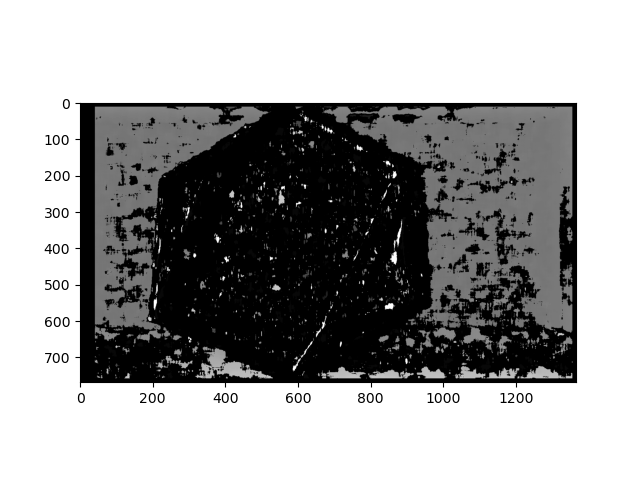

In [4]:
# Load the left and right stereo images
l_image = load_image_gray('1700006810_left.jpg')
r_image = load_image_gray('1700006810_right.jpg')

# Using SereBM
stereoBM = cv2.StereoBM_create( numDisparities=32, blockSize=21 )
disparity_map = stereoBM.compute(l_image, r_image) # Compute disparity map
normalized_disparity_map = cv2.normalize(disparity_map, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

plt.figure()
plt.imshow(normalized_disparity_map, cmap='gray')

<IPython.core.display.Javascript object>


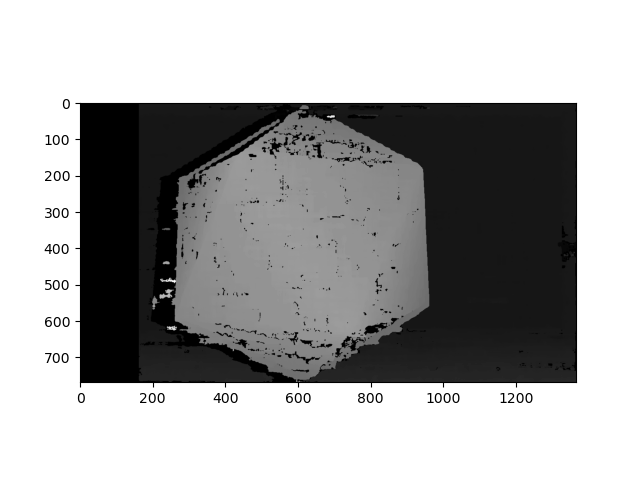

In [5]:
# StereoSGBM parameter configuration (adjust parameters as needed)
stereo = cv2.StereoSGBM_create(
    minDisparity=2,
    numDisparities=160,
    blockSize=11,
    P1=8 * 1 * 9 ** 2,
    P2=32 * 1 * 9 ** 2,
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32,
    preFilterCap=63,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
)

# Compute disparity map
disparity_map = stereo.compute(l_image, r_image)
normalized_disparity_map = cv2.normalize(disparity_map, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

plt.figure()
plt.imshow(normalized_disparity_map, cmap='gray')

<IPython.core.display.Javascript object>


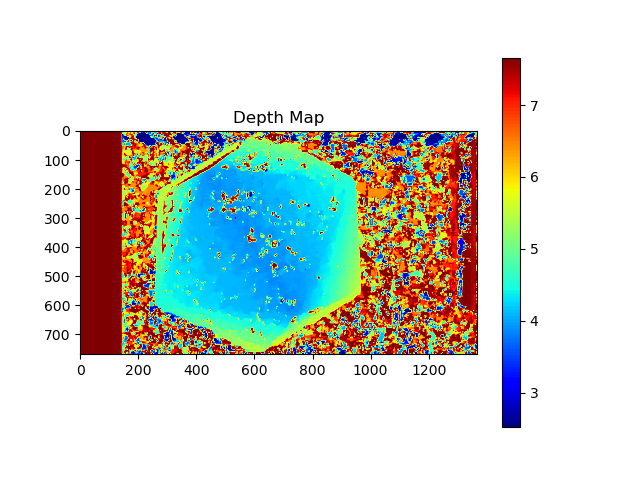

In [24]:
left_image = l_image
right_image = r_image

# Baseline and focal length in mm
baseline = 60  # in mm
focal_length = 6  # in mm

# Disparity range for stereo matching
min_disparity = 48
num_disparities = 96
block_size = 21

# StereoSGBM for computing disparity
stereo = cv2.StereoSGBM_create(
    minDisparity=min_disparity,
    numDisparities=num_disparities,
    blockSize=block_size
)

# Compute disparity
disparity = stereo.compute(left_image, right_image).astype(np.float32) / 16.0  # 16 for SGBM method

# Calculate depth map
depth_map = (focal_length * baseline) / disparity

# Show or save the depth map
# Example to display the depth map using Matplotlib
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(depth_map, cmap='jet')
plt.colorbar()
plt.title('Depth Map')
plt.show()